In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

from astropy.nddata import CCDData
from astropy import units as u
from astropy.table import QTable, vstack
from astropy.wcs.utils import proj_plane_pixel_scales
from astroquery.xmatch import XMatch
from astropy.table import Table

from astroquery.astrometry_net import AstrometryNet

import ccdproc as ccdp

import sep

# phot_circ_radius = 21 # maximum flux extraction for comparing e-/s from sources to theory
phot_circ_radius = 3 # maximum SNR

matplotlib.rcParams.update({'font.size': 12})

%matplotlib inline

### Locate all images

In [2]:
read_path = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'
img_table_solved = QTable.read(read_path + 'tabulated_solved.fits')

In [3]:
default_gain = abs(img_table_solved['GAINFACT'] - 1.0) < 1e-3
default_exp = abs(img_table_solved['EXPTIME'] - 0.1 * u.s) < 1e-3 * u.s
solved = img_table_solved['SOLVED'] > 0
daytime_float = []
for fname in img_table_solved['FILES']:
    if (
        (('10-01_18' in fname)
        or ('10-01_19' in fname)
        or ('10-01_20' in fname)
        or ('10-01_21' in fname)
        or ('10-01_22' in fname)
        or ('10-01_23' in fname)
        or ('10-02_00' in fname))
        # and ('01_20-47' in fname) # kap Lyr
        # and ('10-01_23-43' in fname) # many stars, paper plot
    ):
        daytime_float.append(True)
        # print(fname)
    else:
        daytime_float.append(False)
daytime_float = np.array(daytime_float)
candidates = (default_gain & default_exp & daytime_float & solved)

In [4]:
img_table_solved[candidates]

FOCUSMIN,FOCUS,FOCUSMAX,GAINFACT,EXPTIME,UTC-SEC,UTC-USEC,CCDTEMP,FILES,SOLVE_ATTEMPTED,SOLVED,FILESIZE,TIMESTAMP,RA,DEC,ORIENTATION,SCALE,N_STARS_FOUND,N_STARS_MATCHED,RMSE,BKG_MED,BKG_MEAN,N_STARS_REMATCHED
,,,,s,s,s,deg_C,,,,,s,deg,deg,deg,arcsec / pix,,,arcsec,,,
float64,float64,float64,float64,float64,float64,float64,float64,bytes57,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-7487.0,-12.0,409.0,1.0,0.1000048,1759342187.0,0.773633,15.25,/media/shared/img/saved_image_2025-10-01_18-09-47.fits.fz,1.0,1.0,13299840.0,1759342187.773633,214.8326219750634,3.740820339325287,132.67080789549652,6.78663,20.0,7.0,4.911621694042627,nan,481.5279541015625,7.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343844.0,0.42972899999999997,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-24.fits.fz,1.0,1.0,11649600.0,1759343844.429729,244.98116112987688,46.72205381562287,93.22465445077978,6.79698,16.0,16.0,3.2217194274933254,nan,159.60313415527344,16.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343845.0,0.927994,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-25.fits.fz,1.0,1.0,12640320.0,1759343845.927994,245.0160050754175,46.736635927017446,90.75329904005265,6.8034,25.0,21.0,3.635442920569745,nan,319.71051025390625,23.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343847.0,0.43152199999999996,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-27.fits.fz,1.0,1.0,12640320.0,1759343847.431522,245.04456092037037,46.7458773534598,90.75197140404829,6.80306,32.0,24.0,3.5293127897445515,nan,319.88330078125,28.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343848.0,0.940778,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-29.fits.fz,1.0,1.0,12640320.0,1759343848.940778,245.06180702874738,46.755760332194946,90.74124608478579,6.80323,28.0,22.0,3.575927665259132,nan,319.73974609375,24.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343850.0,0.45574,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-30.fits.fz,1.0,1.0,12640320.0,1759343850.45574,245.0534894027145,46.75527941118355,90.72968721301318,6.80306,27.0,23.0,3.8773332757529864,nan,319.81689453125,23.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343851.0,0.959796,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-32.fits.fz,1.0,1.0,12640320.0,1759343851.959796,245.0333741314571,46.740576773286186,93.17901941608874,6.79778,30.0,25.0,4.044058174471056,nan,319.8036193847656,25.0
-7487.0,-2.0,409.0,1.0,0.1000048,1759343853.0,0.463151,22.5625,/media/shared/img/saved_image_2025-10-01_18-37-33.fits.fz,1.0,1.0,12640320.0,1759343853.463151,244.99584799367588,46.71981239433898,90.72943442020123,6.80355,29.0,22.0,3.8501301369875205,nan,319.7458801269531,26.0


In [5]:
# reduced data path
direc = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/'
calibrated_data = Path(direc)
calibrated_data.mkdir(exist_ok=True)

After an autofocus, one frame is captured with AF settings, and should not be considered. Exclude them on grounds of difference in file size (noise level).

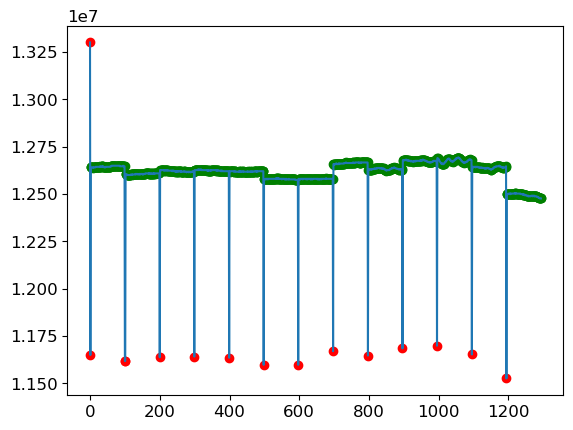

In [6]:
bkg_mean = img_table_solved[candidates]['FILESIZE']
mu, sig = np.mean(bkg_mean), np.std(bkg_mean)
condition = np.abs(bkg_mean - mu) > 3*sig
outliers = np.where(condition)[0]
inliers = np.where(~condition)[0]
plt.figure()
plt.plot(img_table_solved[candidates]['FILESIZE'])
plt.scatter(np.arange(len(img_table_solved[candidates]))[outliers], img_table_solved[candidates][outliers]['FILESIZE'], color='r')
plt.scatter(np.arange(len(img_table_solved[candidates]))[inliers], img_table_solved[candidates][inliers]['FILESIZE'], color='g')
plt.show()

In [7]:
good_files = img_table_solved[candidates][inliers]['FILES']
good_basenames = [os.path.basename(f) for f in good_files]

In [8]:
sci_cal = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/sci/', glob_include=f'*.fits.fz')

### Science: aperture photometry

In [9]:
def get_photometry(in_table, match_radius=20*u.arcsec, RPmag_max=1, RPmag_limit=11):
    query_cat = 'vizier:I/355/gaiadr3'
    # query_cat = 'vizier:I/259/tyc2'
    # query_cat = 'vizier:II/237/colors' # johnson
    results = XMatch.query(
        cat1=in_table,
        colRA1='ra',
        colDec1='dec',
        cat2=query_cat,
        colRA2='RAJ2000',
        colDec2='DEJ2000',
        # colRA2='RA_ICRS',
        # colDec2='DE_ICRS',
        # colRA2='_RA.icrs', # vizier-computed, more accurate would be J1950->J2000 precessed
        # colDec2='_DE.icrs', # vizier-computed, more accurate would be J1950->J2000 precessed
        max_distance=match_radius
    )
    # bluer and redder passbands
    B = results['BPmag']
    R = results['RPmag']
    # B = results['BTmag']
    # R = results['VTmag']
    # R = results['Vmag']
    # B = results['B-V'] + results['Vmag']
    valid = (R < RPmag_limit) & (R > RPmag_max)
    return results[valid], B[valid], R[valid]


def sep_flatfield(img):
    z = img.astype(np.float64)
    opts = dict(
        # bw=78,
        # bh=78,
        # fw=16,
        # fh=16
    )
    flat_data = sep.Background(z, **opts)
    return flat_data

In [10]:
# %matplotlib qt
# plt.ion()
fig, ax = plt.subplots()
ax.axhline(3, linestyle='--', color='k')

all_results = []
for j, sci in enumerate(sci_cal.files):
    if os.path.basename(sci) not in good_basenames:
        # print('skipping', sci)
        continue
    # print(os.path.basename(sci), end='\r')
    ccdobj = CCDData.read(calibrated_data / 'sci' / sci)
    img = ccdobj.data.astype(np.float64)
    # img is in e-/s after cal. SNR must only be calculated on COUNTS, so
    # multiply by exposure time before doing aperture photometry
    img *= ccdobj.header['EXPTIME']

    border = 100
    mask = np.ones_like(img)
    mask[border:-border, border:-border] = 0 # 1-masked elements are ignored
    mask = mask.astype(bool)

    bkg = sep_flatfield(img)

    data_sub = img - bkg.back()

    objects = sep.extract(data_sub, 1., err=bkg.globalrms, mask=mask)

    if len(objects) < 1:
        continue

    # do photometry
    inner = max(20, phot_circ_radius)
    outer = inner + 10
    flux, fluxerr, flag = sep.sum_circle(
        img, objects['x'], objects['y'], phot_circ_radius,
        bkgann=(inner, outer),
        err=bkg.rms(),
        gain=1.0 # background array does not include Poisson uncertainty from source counts, so tell sep to add it in
    )

    # m, s = np.mean(data_sub), np.std(data_sub)
    # figtmp, axtmp = plt.subplots(figsize=(12,6))
    # axtmp.imshow(data_sub, vmin=m-s, vmax=m+5*s, origin='lower')
    # for obj in objects:
    #     circ = matplotlib.patches.Circle(
    #         (obj['x'], obj['y']),
    #         radius=phot_circ_radius, facecolor='none', edgecolor='w')
    #     axtmp.add_artist(circ)
    #     circ = matplotlib.patches.Circle(
    #         (obj['x'], obj['y']),
    #         radius=phot_circ_radius+10, facecolor='none', edgecolor='w', linestyle='--')
    #     axtmp.add_artist(circ)
    # figtmp.show()

    idx_sort = np.argsort(flux)[::-1]
    flux = flux[idx_sort]
    objects = objects[idx_sort]

    instrumental_mags = -2.5 * np.log10(flux)
    # for i in range(len(flux)):
    #     print("object {:d}: flux = {:f} +/- {:f}, SNR {:f}, mag {:f}".format(i, flux[i], fluxerr[i], flux[i] / fluxerr[i], -2.5 * np.log10(flux[i])))

    # observed coorcokdf;knavs;knsma;jjjjjjjjjjjjlodinates
    wcs = ccdobj.wcs
    radec = wcs.pixel_to_world(objects['x'], objects['y'])
    radec_j2000 = radec.transform_to('fk5')
    tab = Table(
        [radec_j2000.ra, radec_j2000.dec, instrumental_mags, flux, fluxerr, objects['flux'], [np.nanmedian(bkg.back())] * len(objects), [sci,] * len(objects)],
        names=['ra', 'dec', 'inst_mag', 'flux', 'fluxerr', 'flux_obj', 'bkg_med', 'file'])
    results, B, R = get_photometry(tab, match_radius=6*u.arcsec)
    # print(results)
    all_results.append(results)

    # if j < np.inf:
    #     # print(results)
    #     ax.scatter(R[results['flux'] > 0], results['flux'][results['flux'] > 0] / results['fluxerr'][results['flux'] > 0], alpha=0.05)
    #     plt.draw()
    #     plt.pause(0.01)

/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_3048053/865514209.py:60: RuntimeWarning:

In [11]:
1/0

ZeroDivisionError: division by zero

In [ ]:
# ax.grid(True)
# ax.set_xlabel('Gaia Rpmag')
# # ax.set_xlabel('Tycho Vmag')
# # ax.set_xlabel('Johnson Vmag')
# ax.set_ylabel('TIMcam SNR')
# ax.set_title('0.1 s, Gain 1x Base')
# ax.set_xlim(3,10)
# ax.set_ylim(0,50)
# plt.show()

In [12]:
combined_results = vstack(all_results)

In [13]:
combined_results

angDist,ra,dec,inst_mag,flux,fluxerr,flux_obj,bkg_med,file,DR3Name,RAdeg,DEdeg,errHalfMaj,errHalfMin,errPosAng,SolID,Source,RandomI,e_RAdeg,e_DEdeg,Plx,e_Plx,RPlx,PM,pmRA,e_pmRA,pmDE,e_pmDE,RADEcor,RAPlxcor,RApmRAcor,RApmDEcor,DEPlxcor,DEpmRAcor,DEpmDEcor,PlxpmRAcor,PlxpmDEcor,pmRApmDEcor,NAL,NAC,NgAL,NbAL,gofAL,chi2AL,epsi,sepsi,Solved,APF,nueff,pscol,e_pscol,RApscolCorr,DEpscolCorr,PlxpscolCorr,pmRApscolCorr,pmDEpscolCorr,MatchObsA,Nper,amax,MatchObs,IPDgofha,IPDgofhp,IPDfmp,IPDfow,RUWE,Dup,o_Gmag,FG,e_FG,RFG,Gmag,e_Gmag,o_BPmag,FBP,e_FBP,RFBP,BPmag,e_BPmag,o_RPmag,FRP,e_FRP,RFRP,RPmag,e_RPmag,E(BP/RP),NBPcont,NBPblend,NRPcont,NRPblend,Mode,BP-RP,BP-G,G-RP,RV,e_RV,n_RV,o_RV,o_RVd,RVNper,RVS/N,RVgof,RVchi2,RVTdur,RVamp,RVtempTeff,RVtemplogg,RVtemp[Fe/H],Vatmparam,vbroad,e_Vbroad,o_Vbroad,GRVSmag,e_GRVSmag,o_GRVSmag,RVSS/N,VarFlag,PQSO,PGal,PSS,Teff,b_Teff,B_Teff,logg,b_logg,B_logg,[Fe/H],b_[Fe/H],B_[Fe/H],Dist,b_Dist,B_Dist,A0,b_A0,B_A0,AG,b_AG,B_AG,E(BP-RP),b_E(BP-RP),B_E(BP-RP),Lib,RAJ2000,DEJ2000,e_RAJ2000,e_DEJ2000,RADEcorJ2000
arcsec,,,,,,,,,,deg,deg,arcsec,arcsec,deg,,,,mas,mas,mas,mas,,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,,,,,,,,,,,,,,,mas,,,,1 / um,1 / um,1 / um,,,,,,,,mas,,,deg,,,,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,electron/s,electron/s,,mag,,,,,,,,mag,mag,mag,km / s,km / s,,,,,,,,d,km / s,K,dex(cm / s2),dex,,km / s,km / s,,mag,mag,,,,,,,K,K,K,dex(cm / s2),dex(cm / s2),dex(cm / s2),dex,dex,dex,pc,pc,pc,mag,mag,mag,mag,mag,mag,mag,mag,mag,,deg,deg,,,
float64,float64,float64,float64,float64,float64,float64,float64,str39,str28,float64,float64,float32,float32,float32,int64,int64,int32,float32,float32,float64,float32,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,int16,int16,int16,float32,float32,float32,float32,uint8,bool,float32,float32,float32,float32,float32,float32,float32,float32,int16,uint8,float32,int16,float32,float32,uint8,uint8,float32,uint8,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,int16,float64,float32,float32,float32,float32,float32,int16,int16,int16,int16,uint8,float32,float32,float32,float32,float32,uint8,int16,int16,uint8,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,uint8,float32,float32,int16,float32,str13,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,str7,float64,float64,float64,float64,float32
3.184554,247.1608779645877,41.880768314172215,-11.498800480876444,39766.75854422213,440.6153195836626,74392.4921875,1904.0030517578125,saved_image_2025-10-01_18-37-25.fits.fz,Gaia DR3 1381119031215320576,247.16079375745,41.88165068792,0.0,0.0,94.0,1636148068921376768,1381119031215320576,881706914,0.2151,0.1979,8.4866,0.2257,37.6065,29.269,28.56,0.291,-6.402,0.284,-0.011,-0.0384,0.5314,0.1155,0.0253,-0.0492,0.0405,-0.0548,0.284,0.319,194,194,191,3,27.9635,109390.0,1.825,4989.6,95,False,--,1.2347,0.0554,0.005,-0.009,0.03,-0.028,-0.077,24,19,0.467767,28,0.1735,98.0,28,0,2.761,0,210,1532776508.19055,11698800.0,131.02,2.72367,0.008733,25,115737000.0,4537780.0,25.5052,5.179862,0.042661,24,1202030000.0,13979300.0,85.9864,2.04811,0.01318,0.86,0,0,0,0,0,3.131752,2.456192,0.675559,--,--,0,0,0,0,--,--,--,--,--,--,--,--,0,--,--,0,--,--,0,--,VARIABLE,0.0,0.0,0.999929,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,--,,247.16062326666,41.88167914304,4.549072,4.54363,0.3237
1.641524,244.93556032472347,46.31383728651846,-10.951912795008287,24030.62786145237,417.96265666978655,31648.951171875,1904.0030517578125,saved_image_2025-10-01_18-37-25.fits.fz,Gaia DR3 1385978666451514112,244.93506863648,46.31353301826,0.0,0.0,28.0,1636148068921376768,1385978666451514112,389345739,0.1447,0.1668,10.1626,0.1825,55.6974,40.731,-13.162,0.173,38.546,0.225,0.2105,0.0215,-0.0499,-0.

In [15]:
combined_results['snr'] = combined_results['flux'] / combined_results['fluxerr']
# combined_results['angDist', 'ra', 'dec', 'snr', 'flux', 'inst_mag', 'DR3Name', 'BPmag', 'RPmag'].pprint_all()
# combined_results['angDist', 'ra', 'dec', 'snr', 'flux', 'inst_mag', 'BTmag', 'VTmag', 'HIP'].pprint_all()
# combined_results['angDist', 'ra', 'dec', 'snr', 'flux', 'inst_mag', 'Vmag', 'B-V'].pprint_all()

[ 4.87772919e+02 -3.01852219e-01 -3.03235192e-01] [[ 6.35716912e+00 -1.78551631e-03  7.02775879e-02]
 [-1.78551631e-03  5.49187996e-07 -2.46230954e-05]
 [ 7.02775879e-02 -2.46230954e-05  1.55137196e-03]]


/tmp/ipykernel_3048053/2373122415.py:4: RuntimeWarning: overflow encountered in power
  return a * 10**(k * vtmag) + b
/tmp/ipykernel_3048053/2373122415.py:4: RuntimeWarning: overflow encountered in multiply
  return a * 10**(k * vtmag) + b


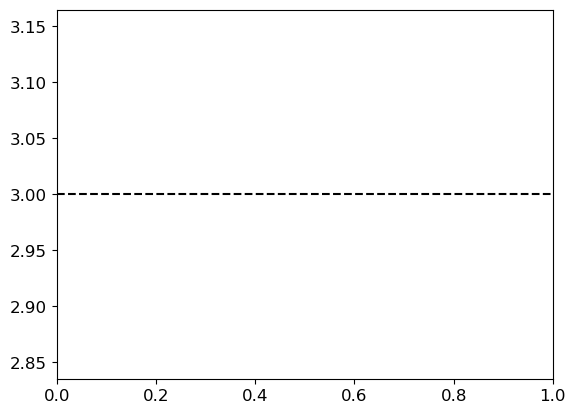

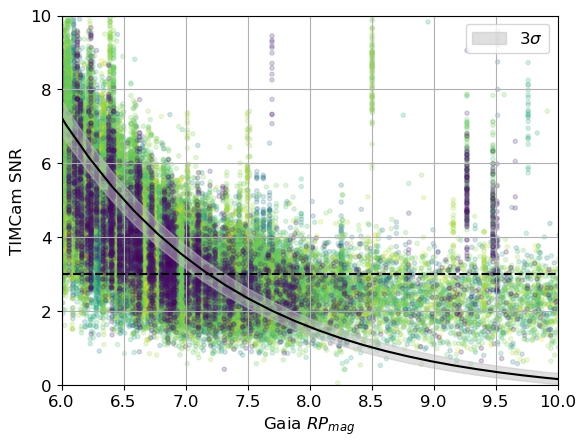

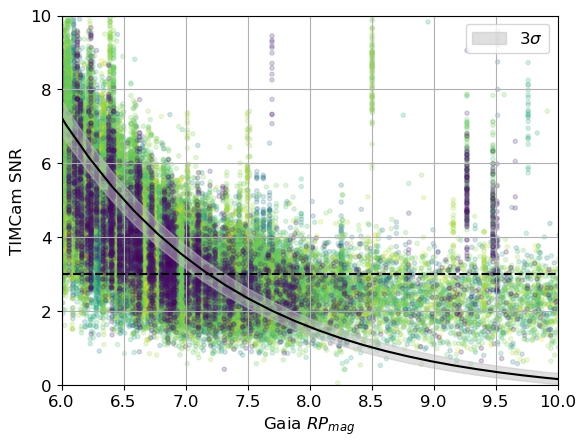

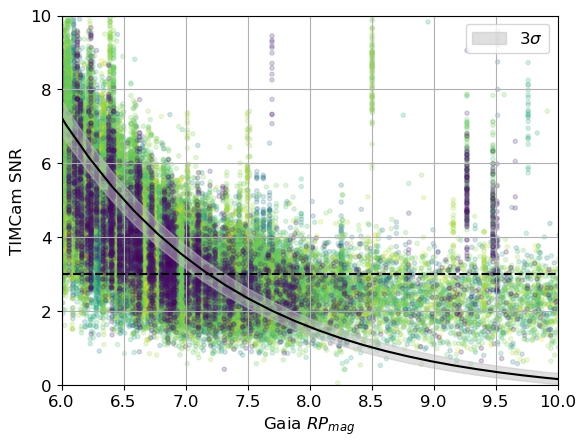

In [18]:
from scipy.optimize import curve_fit

def f(vtmag, a, k, b):
    return a * 10**(k * vtmag) + b

valid = np.where(
    (~np.isnan(combined_results['RPmag'])) &
    (~np.isnan(combined_results['inst_mag'])) &
    (combined_results['snr'] > 0)
)

x = combined_results['RPmag'][valid]
y = combined_results['snr'][valid]
p0 = [50, -1, 0]
popt, pcov = curve_fit(f, x, y, p0)
vmags = np.linspace(2, 11)
print(popt, pcov)
snrs_fit = f(vmags, *popt)

fig, ax = plt.subplots()
# for i, file in enumerate(flux_results_files):
#     combined_results = Table.read(file)
#     snr = combined_results['flux'] / combined_results['fluxerr']
#     ax.scatter(combined_results[snr > 0]['VTmag'], snr[snr > 0], marker='.', alpha=0.3, label=labels[i])
ax.scatter(
    combined_results['RPmag'][valid],
    combined_results['snr'][valid],
    c=combined_results['bkg_med'][valid],
    marker='.',
    alpha=0.2
)
ax.plot(vmags, snrs_fit, color='k')
ax.fill_between(
    vmags,
    f(vmags, *(popt + 3*np.diag(pcov)**.5)),
    f(vmags, *(popt - 3*np.diag(pcov)**.5)),
    color='silver',
    alpha=0.5,
    label='3$\sigma$'
)
ax.set_xlabel('Gaia $RP_{mag}$')
ax.set_ylabel('TIMCam SNR')
ax.set_xlim(6,10)
ax.set_ylim(0,10)
ax.grid(True)
ax.axhline(3, linestyle='--', color='k')
ax.legend()
plt.show()

In [19]:
detected = combined_results['snr'] > 3
# Group measured stars by their file of origin, so we can determine which stars
# are measured with SNR>=3, and what their catalog magnitudes are.
file_groups = combined_results[detected]['file', 'bkg_med', 'RPmag'].group_by('file')
max_mag_per_frame = file_groups.groups.aggregate(np.max)
pct = np.nanpercentile(max_mag_per_frame['RPmag'], (16, 50, 84))

fig, ax = plt.subplots()
ax.hist(max_mag_per_frame['RPmag'], edgecolor='k')
ax.axvline(pct[1], color='k', linestyle='--')
ax.axvline(pct[0], color='darkgrey', linestyle='--')
ax.axvline(pct[-1], color='darkgrey', linestyle='--')

fig, ax = plt.subplots()
ax.plot(max_mag_per_frame['RPmag'])
ax.invert_yaxis()

fig, ax = plt.subplots()
ax.scatter(max_mag_per_frame['bkg_med'], max_mag_per_frame['RPmag'])
ax.invert_yaxis()

print('16-50-84 percentiles', pct)
print(pct[1], f'+{pct[2] - pct[1]}', f'-{pct[1] - pct[0]}')

/home/evanmayer/miniconda3/envs/astr-new/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


16-50-84 percentiles       RPmag       
       mag        
------------------
  7.11607946395874
 8.505024909973145
10.323221054077148
8.505024909973145 +1.8181961441040038 -1.3889454460144046


In [20]:
combined_results.write('combined_100ms_gain1.fits', overwrite=True)

In [21]:
combined_results = Table.read('combined_100ms_gain1.fits')

Check source matching - whatever file was last in the for loop

In [ ]:
corr_file = os.path.join('/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve', sci.replace('.fits.fz', '_funpack_re_solve.corr'))
print(sci)
print(corr_file)
# tbl = fits.open(corr_file)[1]
tbl = QTable.read(corr_file)
print(len(tbl))
# tbl.pprint_all()

m, s = np.median(ccdobj.data.astype(np.float64)), ccdobj.data.astype(np.float64).std()

fig, ax = plt.subplots(layout='compressed', subplot_kw=dict(projection=wcs))
im = ax.imshow(ccdobj.data.astype(np.float64), cmap='bone',
                vmin=m-1*s, vmax=m+4*s)
cb = fig.colorbar(im, ax=ax)
cb.ax.tick_params(labelsize=8)
cb.set_label('e$^{-}$ s$^{-1}$', size=8)
ax.scatter(
    tbl['field_ra'].value * u.deg,
    tbl['field_dec'].value * u.deg,
    s=50,
    marker='o',
    facecolor='none',
    edgecolor='tomato',
    transform=ax.get_transform('world')
)
# ax.tick_params(axis='both', which='major', labelsize=10)
ax.coords[0].set_ticklabel(size=8)
ax.coords[1].set_ticklabel(size=8)
ax.invert_yaxis()

inset = ax.inset_axes([.01, .58, .4, .4], transform=ax.transAxes, alpha=0.5, projection=wcs)
inset.invert_yaxis()
im = inset.imshow(ccdobj.data.astype(np.float64), cmap='bone', vmin=m-1*s, vmax=m+4*s)#, transform=ax.get_transform("world"))
inset.set_xlim(1750, 2350)
inset.set_ylim(2075, 1575)
inset.scatter(
    tbl['field_ra'].value * u.deg,
    tbl['field_dec'].value * u.deg,
    s=50,
    marker='o',
    facecolor='none',
    edgecolor='tomato',
    transform=inset.get_transform('world')
)
inset.set_xticks([])
inset.set_yticks([])
inset.set_xlabel('')
inset.set_ylabel('')
for coord in inset.coords:
    coord.set_ticks_visible(False)
    coord.set_ticklabel_visible(False)
    coord.set_axislabel('')

for spine in inset.spines.values():
    spine.set_color('silver')
    spine.set_linewidth(2)
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
mark_inset(ax, inset, loc1=3, loc2=4, fc="none", ec="0.5")

ax.set_xlabel('Declination (J2000)', fontsize=8)
ax.set_ylabel('Right Ascension (J2000)', fontsize=8)
ax.grid(linestyle=':')
ax.set_title('t = 1759362235.439111 (UNIX)', fontsize=8)

plt.savefig(sci + '_highlight.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from astropy.coordinates import AltAz, SkyCoord, EarthLocation, get_body
from astropy.time import Time

fts = (34.49,-104.22)
FLOAT_ALT = 37.8 * u.km
launch_location = EarthLocation(lat=fts[0], lon=fts[1], height=FLOAT_ALT)
# ts = Time(all_results['ts'], format='unix', scale='utc', location=launch_location)
ts = Time(np.array([1759362235.439111,]) * u.s, format='unix', location=launch_location)
coords = [(wcs.wcs.crval[0] * u.deg, wcs.wcs.crval[1] * u.deg,),]
print(coords)
aa = AltAz(obstime=ts, location=launch_location)

boresight = SkyCoord(coords)
boresight_altaz = boresight.transform_to(aa)

sun = get_body('sun', ts, launch_location)
sun_altaz = sun.transform_to(aa)

sza = (90*u.deg - sun_altaz.alt)

# fig, ax = plt.subplots(figsize=(12,5))
# ax.plot(ts, sun_altaz.alt, label='Sun Alt.')
# ax.plot(ts, sza, label='Solar Zenith Angle')
# ax.legend()

# fig, ax = plt.subplots(figsize=(12,5))
# ax.plot(ts, sun_altaz.az, label='Sun Az.')
# ax.plot(ts, boresight_altaz.az, label='Boresight Az.')
# ax.legend()

# fig, ax = plt.subplots(figsize=(12,5))
vza = 90*u.deg - boresight_altaz.alt
vaz = sun_altaz.az - boresight_altaz.az
# im = ax.scatter(vaz, vza)
# ax.grid(True)
# fig.colorbar(im, ax=ax, label='$I_{\lambda}$')
# ax.set_title(f'Mean solar zenith angle: {sza.mean().deg:.2f}')
# # ax.set_xlim(0, 200)
# # ax.set_ylim(20, 70)
# ax.set_xlabel('View Sun-Relative Azimuth')
# ax.set_ylabel('View Zenith Angle')

print(vza.deg, vaz.deg, sza.deg)

In [ ]:
len(radec), len(results)
len(objects)

In [ ]:
# from io import StringIO
# # circular annulus r + 3
# # r, snr, flux
# s = '''
# 2 39 40594
# 3 37 57903
# 4 35 77488
# 5 35 101747
# 6 33 121378
# 7 31 138431
# 8 28 149506
# 9 27 165275
# 10 25 176591
# 15 17 209904
# 20 13 233666
# 21 12 234790
# 22 11 222036
# 25 8 212941
# '''
# r, snr, f = np.genfromtxt(StringIO(s), delimiter=' ', names=['r', 'snr', 'f'], unpack=True)

# fig, ax = plt.subplots()
# ax2 = ax.twinx()
# ax.plot(r, snr, label='snr')
# ax.set_ylabel('SNR')
# ax2.plot(r, f, color='r', label='flux')
# ax2.set_ylabel('Flux (e-/s in aperture)')
# ax.set_xlabel('circular radius (px)')
# fig.tight_layout()
# plt.show()

Quick check of linearity and color

In [22]:
non_nans = np.where((~np.isnan(combined_results['BPmag'])) & (~np.isnan(combined_results['RPmag'])) & (~np.isnan(combined_results['inst_mag'])))
# non_nans = np.where((~np.isnan(combined_results['BTmag'])) & (~np.isnan(combined_results['VTmag'])) & (~np.isnan(combined_results['inst_mag'])))
# non_nans = np.where((~np.isnan(combined_results['Vmag'])) & (~np.isnan(combined_results['RPmag'])) & (~np.isnan(combined_results['inst_mag'])))

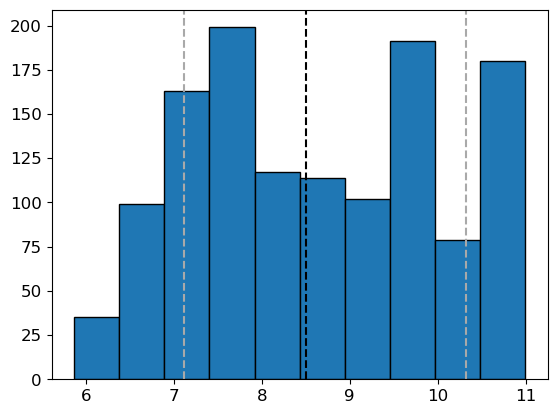

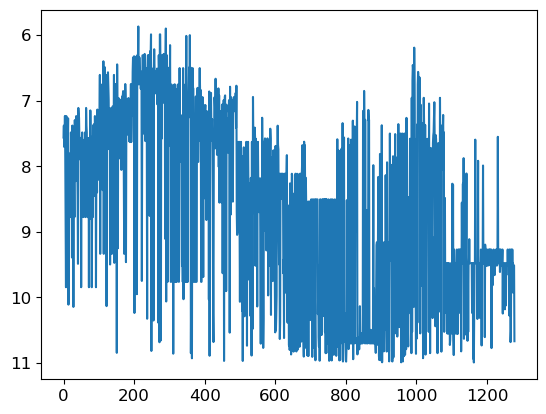

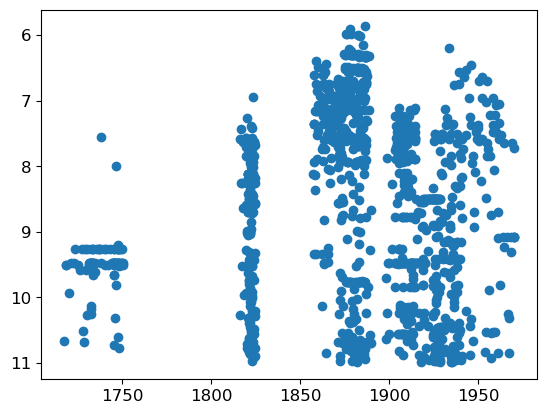

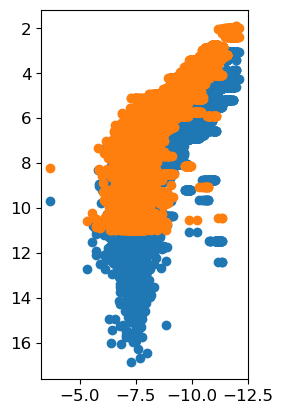

In [23]:
fig, ax = plt.subplots()
ax.scatter(combined_results['inst_mag'][non_nans], combined_results['BPmag'][non_nans])
ax.scatter(combined_results['inst_mag'][non_nans], combined_results['RPmag'][non_nans])
# ax.scatter(combined_results['inst_mag'], combined_results['BTmag'])
# ax.scatter(combined_results['inst_mag'], combined_results['VTmag'])
# ax.scatter(combined_results['inst_mag'][non_nans], combined_results['BPmag'][non_nans])
# ax.scatter(combined_results['inst_mag'][non_nans], combined_results['RPmag'][non_nans])
# ax.scatter(results['inst_mag'], results['BPmag'] - results['RPmag'])
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

Fit for our red filter zero-point, referred to the Gaia red filter system with a color correction term

In [24]:
len(non_nans[0]), len(combined_results)

(85374, 85529)

[-15.18832438   0.34860767  -0.02832599] [[ 2.61137140e-05 -2.41915123e-05  4.26040713e-06]
 [-2.41915123e-05  3.50828059e-05 -7.96920558e-06]
 [ 4.26040713e-06 -7.96920558e-06  2.35398028e-06]] [0.00511016 0.00592307 0.00153427]


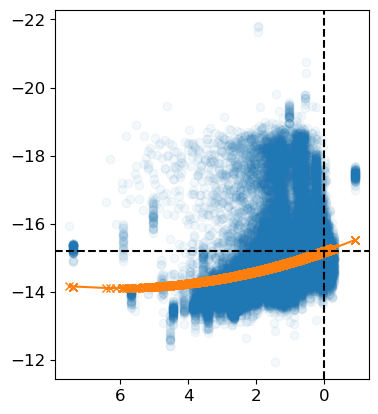

In [25]:
# 10.1146/annurev.astro.41.082801.100251
from scipy.optimize import curve_fit

def f(x, ZP, a, b):
    return ZP + a * x + b * x**2

# B0 - B = ZP + a(B - V)
# B0 - B = ZP + aB - aV
# B0 - ZP + aV = aB + B
# (B0 - ZP + aV) / (a + 1) = B

p0 = [0, 0.5, 0.0]
xdata = combined_results['BPmag'][non_nans] - combined_results['RPmag'][non_nans]
ydata = combined_results['inst_mag'][non_nans] - combined_results['RPmag'][non_nans]
# xdata = combined_results['BTmag'][non_nans] - combined_results['VTmag'][non_nans]
# ydata = combined_results['inst_mag'][non_nans] - combined_results['VTmag'][non_nans]
popt, pcov = curve_fit(f, xdata, ydata, p0)
ZP_fit, a_fit, b_fit = popt
print(popt, pcov, np.diag(pcov)**.5)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata, alpha=0.05)
ax.plot(sorted(xdata), f(np.array(sorted(xdata)), popt[0], popt[1], popt[2]), color='C1', marker='x')
ax.axvline(0, linestyle='--', color='k')
ax.axhline(ZP_fit, linestyle='--', color='k')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

Check results: a good transformation should intersect at y = 0 and have slope = 1

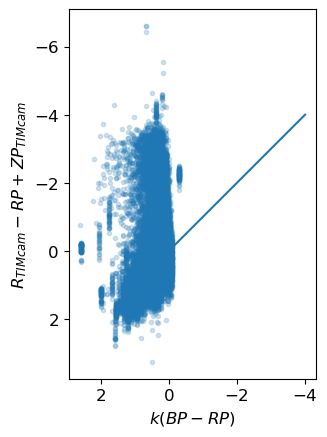

In [26]:
fig, ax = plt.subplots()
ax.scatter(
    a_fit*(combined_results['BPmag'] - combined_results['RPmag']),# + b_fit*(combined_results['BPmag'] - combined_results['RPmag'])**2,
    (combined_results['inst_mag'] - combined_results['RPmag']) + -ZP_fit,
    # a_fit*(combined_results['BTmag'] - combined_results['VTmag']) + b_fit*(combined_results['BTmag'] - combined_results['VTmag'])**2,
    # (combined_results['inst_mag'] - combined_results['VTmag']) + -ZP_fit,
    alpha=0.2,
    marker='.'
)
ax.plot(np.linspace(0,-4), np.linspace(0,-4))
ax.set_xlabel('$k(BP - RP)$')
ax.set_ylabel('$R_{TIMcam} - RP + ZP_{TIMcam}$')
# ax.set_xlabel('$k(B_T - V_T)$')
# ax.set_ylabel('$R_{TIMcam} - V_T + ZP_{TIMcam}$')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

In [ ]:
# plt.figure()
# # putative_filt = (combined_results['inst_mag'][non_nans] - ZP_fit + a_fit * combined_results['RPmag'][non_nans]) / (a_fit + 1)
# # plt.scatter(putative_filt, combined_results['RPmag'][non_nans], alpha=0.05)
# putative_filt = (combined_results['inst_mag'][non_nans] - ZP_fit + a_fit * combined_results['VTmag'][non_nans]) / (a_fit + 1)
# plt.scatter(putative_filt, combined_results['VTmag'][non_nans], alpha=0.05)
# plt.plot(np.arange(0,10), np.arange(0,10), color='C1')
# plt.show()

In [ ]:
# plt.figure()
# plt.hist(putative_filt, bins=10)
# plt.show()
# len(putative_filt)

In [ ]:
# putative_filt.max()

Spot check: convert sky brightness into filter magnitudes/arcsec^2

In [ ]:
# need flipud to show people which way is down because readout of frame lines was inverted
bkg_rate_e_per_s = np.flipud(bkg.back() / ccdobj.header['EXPTIME'])

fig, ax = plt.subplots()
im = ax.imshow(bkg_rate_e_per_s, origin='lower', interpolation='none')
fig.colorbar(im, ax=ax)
ax.set_title('Background counts: e-/s')

ps_arcsec_per_px = np.mean(proj_plane_pixel_scales(wcs) * 3600) # arcsec/px
print(ps_arcsec_per_px)

# rate per arcsec^2
bkg_rate_per_arcsec2 = bkg_rate_e_per_s / ps_arcsec_per_px**2

fig, ax = plt.subplots()
im = ax.imshow(bkg_rate_per_arcsec2, origin='lower', interpolation='none', cmap='bone')
fig.colorbar(im, ax=ax)
ax.set_title('Background counts: e-/s/(arcsec^2)')

mu = -2.5 * np.log10(bkg_rate_per_arcsec2) - ZP_fit

fig, ax = plt.subplots()
im = ax.imshow(mu, origin='lower', interpolation='none', cmap='viridis_r')
cb = fig.colorbar(im, ax=ax)
cb.ax.invert_yaxis()
ax.set_title('Background counts: mag/arcsec^2')
print(mu.max(), mu.min())

plt.show()

Plot max, min, and median sky mags over time

In [27]:
ps_arcsec_per_px2 = np.mean(proj_plane_pixel_scales(wcs) * 3600)**2 # arcsec/px

all_mu_maps = []
all_bkg_maps = []
for j, sci in enumerate(sci_cal.files):
    if os.path.basename(sci) not in good_basenames:
        print('skipping', sci)
        continue
    ccdobj = CCDData.read(calibrated_data / 'sci' / sci)
    print(j / len(sci_cal.files), ccdobj.header['EXPTIME'], sci, end='\r')
    img = ccdobj.data
    # img is now in e-/s

    border = 100
    mask = np.ones_like(img)
    mask[border:-border, border:-border] = 0 # 1-masked elements are ignored
    mask = mask.astype(bool)

    bkg = sep_flatfield(img)
    # e- / s in each px
    bkg_rate_e_per_s = bkg.back()
    print(bkg_rate_e_per_s)
    # rate per arcsec^2
    bkg_rate_per_arcsec2 = bkg_rate_e_per_s / ps_arcsec_per_px2
    # in magnitudes with zero point correction
    mu = -2.5 * np.log10(bkg_rate_per_arcsec2) - ZP_fit
    all_mu_maps.append((mu.max(), np.median(mu), np.mean(mu), mu.min()))
    all_bkg_maps.append((bkg_rate_per_arcsec2.max(), np.median(bkg_rate_per_arcsec2), np.mean(bkg_rate_per_arcsec2), bkg_rate_per_arcsec2.min(), bkg.globalback / ps_arcsec_per_px2))

skipping saved_image_2025-10-01_18-07-15.fits.fz
skipping saved_image_2025-10-01_18-10-43.fits.fz
skipping saved_image_2025-10-01_18-11-56.fits.fz
skipping saved_image_2025-10-01_18-12-12.fits.fz
skipping saved_image_2025-10-01_18-12-24.fits.fz
skipping saved_image_2025-10-01_18-12-39.fits.fz
skipping saved_image_2025-10-01_18-12-55.fits.fz
skipping saved_image_2025-10-01_18-13-10.fits.fz
skipping saved_image_2025-10-01_18-13-25.fits.fz
skipping saved_image_2025-10-01_18-13-40.fits.fz
skipping saved_image_2025-10-01_18-13-55.fits.fz
skipping saved_image_2025-10-01_18-14-10.fits.fz
skipping saved_image_2025-10-01_18-14-25.fits.fz
skipping saved_image_2025-10-01_18-14-40.fits.fz
skipping saved_image_2025-10-01_18-14-55.fits.fz
skipping saved_image_2025-10-01_18-15-11.fits.fz
skipping saved_image_2025-10-01_18-15-26.fits.fz
skipping saved_image_2025-10-01_18-15-41.fits.fz
skipping saved_image_2025-10-01_18-15-56.fits.fz
skipping saved_image_2025-10-01_18-16-11.fits.fz
skipping saved_image

In [31]:
ts = img_table_solved[candidates][inliers]['TIMESTAMP'][::].value
# img_table_solved[candidates][inliers]['FILES']
len(ts)

1279

In [32]:
len(all_mu_maps)

1279

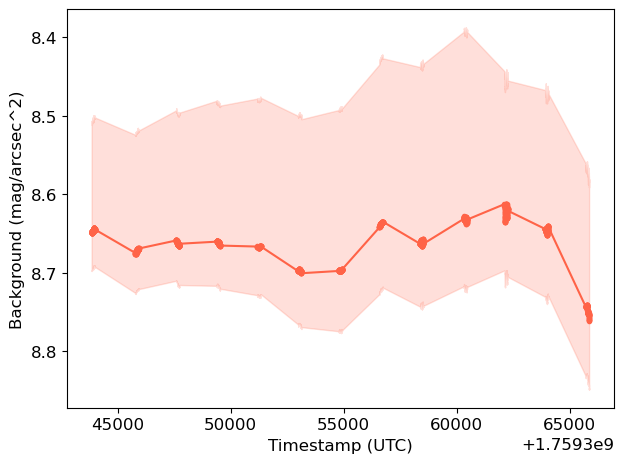

In [36]:
fig, ax = plt.subplots()
mins = [minn for maxx, medd, meann, minn in all_mu_maps]
meds =[medd for maxx, medd, meann, minn in all_mu_maps]
means =[meann for maxx, medd, meann, minn in all_mu_maps]
maxs = [maxx for maxx, medd, meann, minn in all_mu_maps]
ax.fill_between(ts, maxs, mins, alpha=0.2, color='tomato')
ax.plot(ts, meds, marker='.', color='tomato')
# ax.fill_between(range(len(maxs)), maxs, mins, alpha=0.2, color='tomato')
# ax.plot(range(len(meds)), meds, marker='.', color='tomato')
ax.invert_yaxis()
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Background (mag/arcsec^2)')
fig.tight_layout()
plt.show()

In [37]:
maps_reduced = Table((ts, mins, meds, means, maxs), names=['ts', 'mins', 'meds', 'means', 'maxs'])
maps_reduced.write('bkg_summary_mag_arcsec2_100ms_gain1.fits', overwrite=True)

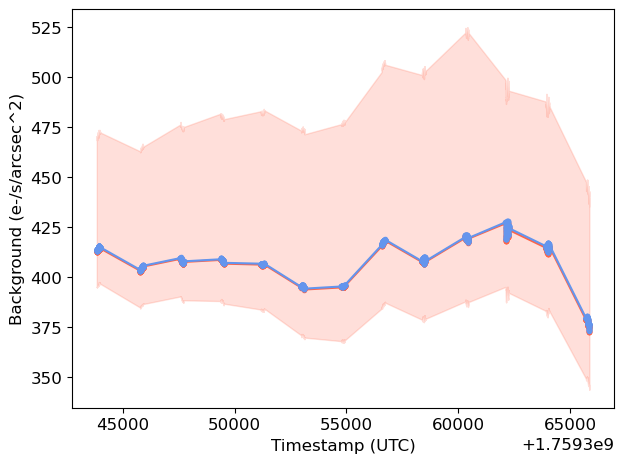

In [38]:
fig, ax = plt.subplots()
mins = [minn for maxx, medd, meann, minn, gback in all_bkg_maps]
meds =[medd for maxx, medd, meann, minn, gback in all_bkg_maps]
means =[meann for maxx, medd, meann, minn, gback in all_bkg_maps]
maxs = [maxx for maxx, medd, meann, minn, gback in all_bkg_maps]
gbacks = [gback for maxx, medd, meann, minn, gback in all_bkg_maps]
ax.fill_between(ts, maxs, mins, alpha=0.2, color='tomato')
ax.plot(ts, meds, marker='.', color='tomato')
ax.plot(ts, gbacks, marker='.', color='cornflowerblue')
# ax.fill_between(range(len(maxs)), maxs, mins, alpha=0.2, color='tomato')
# ax.plot(range(len(meds)), meds, marker='.', color='tomato')
# ax.invert_yaxis()
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Background (e-/s/arcsec^2)')
fig.tight_layout()
plt.show()

In [39]:
maps_reduced = Table((ts, mins, meds, means, maxs, gbacks), names=['ts', 'mins', 'meds', 'means', 'maxs', 'gbacks'])
maps_reduced.write('bkg_summary_e-_s_arcsec2_100ms_gain1.fits', overwrite=True)

In [40]:
%matplotlib qt

fig, (ax, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
exps = [
    'bkg_summary_e-_s_arcsec2_50ms_gain1.fits',
    'bkg_summary_e-_s_arcsec2_100ms_gain1.fits',
    'bkg_summary_e-_s_arcsec2_200ms_gain1.fits',
    'bkg_summary_e-_s_arcsec2_50ms_gain2.fits',
    'bkg_summary_e-_s_arcsec2_100ms_gain2.fits',
    'bkg_summary_e-_s_arcsec2_200ms_gain2.fits',
    'bkg_summary_e-_s_arcsec2_50ms_gain4.fits',
    'bkg_summary_e-_s_arcsec2_100ms_gain4.fits',
    'bkg_summary_e-_s_arcsec2_200ms_gain4.fits'
]
labels = [
    '50 ms, gain 1',
    '100 ms, gain 1',
    '200 ms, gain 1',
    '50 ms, gain 2',
    '100 ms, gain 2',
    '200 ms, gain 2',
    '50 ms, gain 4',
    '100 ms, gain 4',
    '200 ms, gain 4'
]
for i, exp in enumerate(exps):
    maps_reduced = Table.read(exp)
    ts, mins, meds, means, maxs, gbacks = maps_reduced['ts'], maps_reduced['mins'], maps_reduced['meds'], maps_reduced['means'], maps_reduced['maxs'], maps_reduced['gbacks']
    ax.fill_between(ts, maxs, mins, alpha=0.2, color=f'C{i}', zorder=0)
    ax1.fill_between(ts, -2.5 * np.log10(maxs), -2.5 * np.log10(mins), alpha=0.2, color=f'C{i}', zorder=0)
    ax.scatter(ts, meds, marker='.', color=f'C{i}', label=labels[i], zorder=99)
    ax1.scatter(ts, -2.5 * np.log10(meds), marker='.', color=f'C{i}', zorder=99)
ax.set_ylabel('Background\n(e-/s/arcsec^2)')
ax1.set_xlabel('Timestamp (UTC)')
ax1.invert_yaxis()
ax1.set_ylabel('Instrumental Magnitudes\n(mag/arcsec^2)')

x = img_table_solved['TIMESTAMP'].value
y = img_table_solved['BKG_MEAN'].value# / img_table_solved['EXPTIME'].value / img_table_solved['GAINFACT'].value
ax2.scatter(x, y, c=(img_table_solved['FOCUSMAX'].value - img_table_solved['FOCUS'].value), cmap='viridis')
ax2.set_xlabel('t')
ax2.set_ylabel('ADU')

plt.figlegend(loc='center right')
fig.tight_layout()
plt.show()

In [41]:
meds.mean() # e-/s/arcsec^2

np.float64(406.30958912327844)

In [ ]:
1/0

All flux measurements together

In [42]:
flux_results_files = [
    'combined_50ms_gain1.fits',
    'combined_100ms_gain1.fits',
    'combined_200ms_gain1.fits',
    'combined_50ms_gain2.fits',
    'combined_100ms_gain2.fits',
    'combined_200ms_gain2.fits',
    'combined_50ms_gain4.fits',
    'combined_100ms_gain4.fits',
    'combined_200ms_gain4.fits',
]
labels = [
    '50 ms, gain 1',
    '100 ms, gain 1',
    '200 ms, gain 1',
    '50 ms, gain 2',
    '100 ms, gain 2',
    '200 ms, gain 2',
    '50 ms, gain 4',
    '100 ms, gain 4',
    '200 ms, gain 4'
]

In [43]:
fig, ax = plt.subplots()
for i, file in enumerate(flux_results_files):
    combined_results = Table.read(file)
    try:
        ax.scatter(combined_results['RPmag'], combined_results['inst_mag'], marker='.', alpha=0.3, label=labels[i])
    except:
        pass
    # ax.scatter(combined_results['VTmag'], combined_results['inst_mag'], marker='.', alpha=0.3, label=labels[i])
ax.set_xlabel('Gaia $RP_{mag}$')
# ax.set_xlabel('Tycho $V_{mag}$')
ax.set_ylabel('TIMcam mag')
ax.set_xlim(3,9)
# ax.set_ylim(0,50)
ax.grid(True)
ax.axhline(3, linestyle='--', color='silver')
ax.legend()

In [44]:
from scipy.optimize import curve_fit

all_VTs = []
all_BTs = []
all_Ts = []
all_snrs = []
for i, file in enumerate(flux_results_files):
    combined_results = Table.read(file)
    combined_results['snr'] = combined_results['flux'] / combined_results['fluxerr']
    all_VTs.append(combined_results['VTmag'])
    all_BTs.append(combined_results['BTmag'])
    all_Ts.append(combined_results['inst_mag'])
    all_snrs.append(combined_results['snr'])
all_VTs = vstack(all_VTs)
all_BTs = vstack(all_BTs)
all_Ts = vstack(all_Ts)
all_snrs = vstack(all_snrs)
valid = np.where(
    (~np.isnan(all_VTs['VTmag'])) &
    (~np.isnan(all_BTs['BTmag'])) &
    (~np.isnan(all_Ts['inst_mag'])) &
    (all_snrs['snr'] > 0)
)

def f(x, ZP, a, b):
    return ZP + a * x + b * x**2

# B0 - B = ZP + a(B - V)
# B0 - B = ZP + aB - aV
# B0 - ZP + aV = aB + B
# (B0 - ZP + aV) / (a + 1) = B

p0 = [0, 0.5, 0.0]
# xdata = combined_results['BPmag'][non_nans] - combined_results['RPmag'][non_nans]
# ydata = combined_results['inst_mag'][non_nans] - combined_results['RPmag'][non_nans]
xdata = all_BTs['BTmag'][valid] - all_VTs['VTmag'][valid]
ydata = all_Ts['inst_mag'][valid] - all_VTs['VTmag'][valid]
popt, pcov = curve_fit(f, xdata, ydata, p0)
ZP_fit, a_fit, b_fit = popt
print(popt, pcov, np.diag(pcov)**.5)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata, alpha=0.05)
x = np.linspace(xdata.min(), xdata.max())
ax.plot(x, f(x, popt[0], popt[1], popt[2]), color='C1', marker='x')
ax.axvline(0, linestyle='--', color='k')
ax.axhline(ZP_fit, linestyle='--', color='k')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_xlabel('B-V')
ax.set_ylabel('T-V')
ax.set_aspect('equal')
plt.show()

KeyError: 'VTmag'

In [45]:
fig, ax = plt.subplots()
ax.hist(all_Ts['inst_mag'][valid] - ZP_fit, bins=np.arange(0,9+1), density=True, edgecolor='k')
ax.set_xlabel('B+W091 Magnitudes')
ax.set_ylabel('Relative Frequency')

TypeError: list indices must be integers or slices, not str

In [ ]:
fig, ax = plt.subplots()
ax.hist(all_VTs['VTmag'][valid], bins=np.arange(0,9+1), density=True, edgecolor='k')
ax.set_xlabel('Tycho $V_{mag}$')
ax.set_ylabel('Relative Frequency')

In [ ]:
def f(vtmag, a, k, b):
    return a * 10**(k * vtmag) + b

x = all_VTs['VTmag'][valid]
y = all_snrs['snr'][valid]
p0 = [50, -1, 0]
popt, pcov = curve_fit(f, x, y, p0)
vmags = np.linspace(2, 9)
print(popt, pcov)
snrs_fit = f(vmags, *popt)

fig, ax = plt.subplots()
# for i, file in enumerate(flux_results_files):
#     combined_results = Table.read(file)
#     snr = combined_results['flux'] / combined_results['fluxerr']
#     ax.scatter(combined_results[snr > 0]['VTmag'], snr[snr > 0], marker='.', alpha=0.3, label=labels[i])
ax.scatter(all_VTs['VTmag'][valid], all_snrs['snr'][valid], marker='.', alpha=0.2)
ax.plot(vmags, snrs_fit, color='k')
ax.set_xlabel('Tycho $V_{mag}$')
ax.set_ylabel('TIMcam SNR')
ax.set_xlim(3,9)
ax.set_ylim(0,50)
ax.grid(True)
ax.axhline(3, linestyle='--', color='silver')
ax.legend()

In [ ]:
f(6.45, *popt)